## Problem and Motivation
### Problem Description
This report addresses the regression problem of predicting a song's popularity score on Spotify based on its features, using a dataset of charting songs spanning the 1950s to the 2010s. The popularity score ( `pop` ) is a metric that reflects the popularity of a song on Spotify, ranging from 0 to 100. It is based on the total stream counts weighted towards recent listening activity.
### Motivation
Understanding what makes a song popular has clear commercial value for artists, record labels, and streaming platforms alike. By identifying which measurable charactacteristics of a song relate to its popularity, we can build a model that quantifies these relationships empirically, rather than relying solely on intuition and hopeful speculation.
### Primary Question
**Can we predict a song's Spotify popularity from its audio features and the decade it was released?**
### Data
The dataset is a unification of seven .csv files, each containing songs from a decade from 1950s to 2010s, sourced from Spotify's API via Kaggle. Each row represents a charting song and includes audio features such as energy, danceability, acousticness, and tempo, alongside a popularity score. Files were combined into a single dataset for analysis, with a `decade` column dervied from the source file to perserve chronological information.

The dataset is available publicly on [Kaggle](https://www.kaggle.com/datasets/cnic92/spotify-past-decades-songs-50s10s).
### Limitations
It is important to acknowledge that Spotify's popularity score reflects **_recent_** stream counts rather than a timeless measure of quality. According to Spotify's API documentation, as cited by Musicstax, the popularity score is _"...based, the most part, on the total number of plays the track has had and how recent those plays are."_ ([Musicstax,2024](https://musicat.musicstax.com/spotify-popularity-index))

## Data Loading and Merging
The seven files are combined into a single dataframe with a `decade` column derived from each filename before merging, keeping timeline information that would otherwise be lost.

In [1]:
# Initial import for data ingestion
import pandas as pd

In [2]:
# Read in .csv files
df_1950s = pd.read_csv("data/1950.csv")
df_1960s = pd.read_csv("data/1960.csv")
df_1970s = pd.read_csv("data/1970.csv")
df_1980s = pd.read_csv("data/1980.csv")
df_1990s = pd.read_csv("data/1990.csv")
df_2000s = pd.read_csv("data/2000.csv")
df_2010s = pd.read_csv("data/2010.csv")

# Create list of dfs and decades
dfs = [df_1950s, df_1960s, df_1970s, df_1980s, df_1990s, df_2000s, df_2010s]
decades = [1950, 1960, 1970, 1980, 1990, 2000, 2010]

# Loop through dfs and add decade column
for df in dfs:
    df["decade"] = decades.pop(0)

# Combine the dataset
combined_df = pd.concat(dfs, ignore_index=True)
print(combined_df.shape)

(667, 16)


## Data Cleaning
### Duplicates and Redundant Columns
Seven songs appeared across multiple decade files due to re-releases. Duplicates were identified on `title` and `artist`, retaining the earliest release year to preserve the original recording context. The `Number` column was removed as it was redundant.

In [3]:
# Number column removed — relic from combining datasets
combined_df = combined_df.drop(columns=["Number"])

# 7 duplicate songs identified across decade files — keep earliest release year
combined_df = combined_df.sort_values("year", ascending=True)
combined_df = combined_df.drop_duplicates(subset=["title", "artist"], keep="first")
combined_df = combined_df.reset_index(drop=True)

# Verify no duplicates remain
assert combined_df.duplicated(["title", "artist"]).sum() == 0, "Duplicates remain!"
print(f"Duplicates removed. Dataset: {combined_df.shape[0]} rows × {combined_df.shape[1]} columns.")

Duplicates removed. Dataset: 660 rows × 15 columns.


### Missing Values
A null check revealed missing values only in `top genre`. Rather than dropping these rows, missing genres were labelled `"unknown"`, a valid category a model can learn from. No numeric features contained missing values, so no
imputation was required.

In [4]:
# Missing values found only in `top genre` — labelled "unknown".
combined_df["top genre"] = combined_df["top genre"].fillna("unknown")

assert combined_df.isnull().sum().sum() == 0, "Missing values remain!"
print("No missing values remain.")

No missing values remain.


### Incoherent Years
The assignment notes that some `year` values are incoherent due to re-releases. The `decade` column derived from the source filename is used as the authoritative record of when a song was released. Incoherent years are flagged rather than
corrected, with `decade` used in modelling instead of `year`.

In [5]:
# Keep all columns - add incoherent_year flag column
combined_df["incoherent_year"] = combined_df.apply(
    # If year is less than decade or greater than decade + 9, flag as incoherent
    lambda row: 1 if row["year"] < row["decade"] or row["year"] > row["decade"] + 9 else 0,
    axis=1)   # Apply to each row

print(f"{combined_df['incoherent_year'].sum()} incoherent years ({(combined_df['incoherent_year'].mean()*100):.1f}% of dataset)")

189 incoherent years (28.6% of dataset)


## Exploratory Data Analysis
Before modelling, the data was explored to understand the target variable, feature distributions, and relationships between features and popularity. Each finding directly informed later modelling decisions.

In [6]:
# EDA imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Consistent styles across plots
sns.set_theme(style="whitegrid", palette="muted")

### Target Distribution

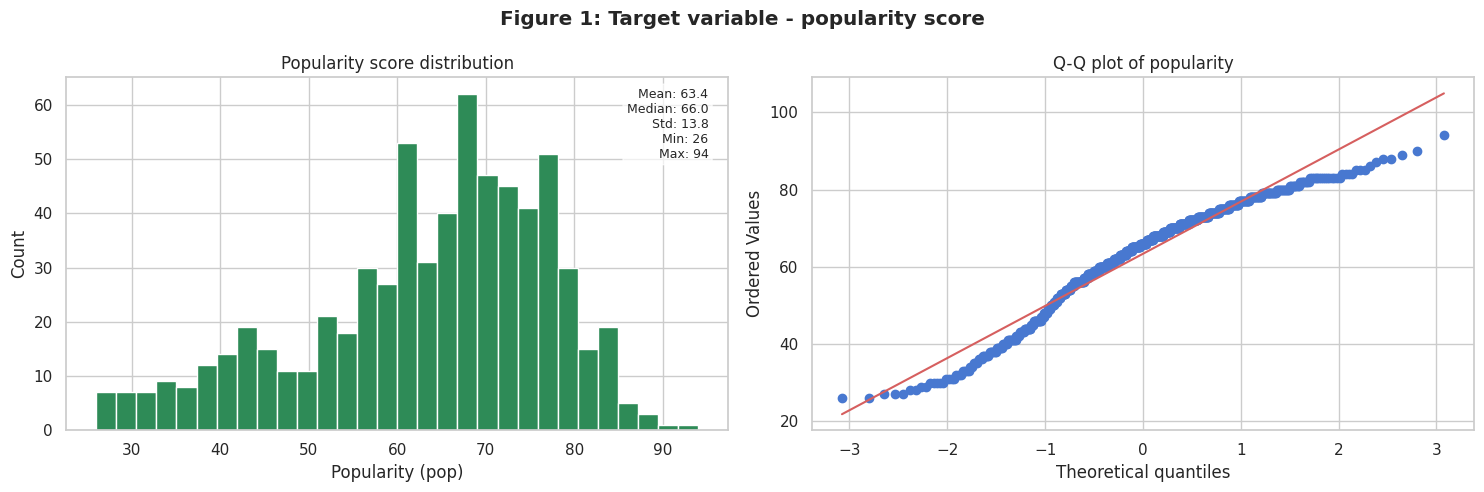

In [7]:
### Popularity distribution ###

# Figure - side by side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of pop
axes[0].hist(combined_df["pop"], bins=30, color="seagreen", edgecolor="white")
axes[0].set_title("Popularity score distribution")
axes[0].set_xlabel("Popularity (pop)")
axes[0].set_ylabel("Count")

# Add summary stats text box
stats = combined_df["pop"].describe()
textstr = "\n".join([
    f"Mean: {stats['mean']:.1f}",
    f"Median: {stats['50%']:.1f}",
    f"Std: {stats['std']:.1f}",
    f"Min: {stats['min']:.0f}",
    f"Max: {stats['max']:.0f}",
])

# Position text box top right
axes[0].text(0.97, 0.97, textstr, transform=axes[0].transAxes,  # use axes co-ordinatess
             fontsize=9, verticalalignment="top", horizontalalignment="right",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# Q-Q plot to assess normality of pop
from scipy import stats as scipy_stats
scipy_stats.probplot(combined_df["pop"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot of popularity")

plt.suptitle("Figure 1: Target variable - popularity score", fontweight="bold")
plt.tight_layout()
plt.show()

Popularity scores are left-skewed (mean=63.4, median=66.0), indicating most songs in this curated dataset achieve moderate-to-high popularity. This is expected given it comprises charting songs rather than a random sample. The Q-Q plot confirms departure from normality, which motivates reporting both RMSE and MAE as evaluation metrics, as MAE is more robust to skewed distributions. Both metrics will be reported.
### Popularity by decade

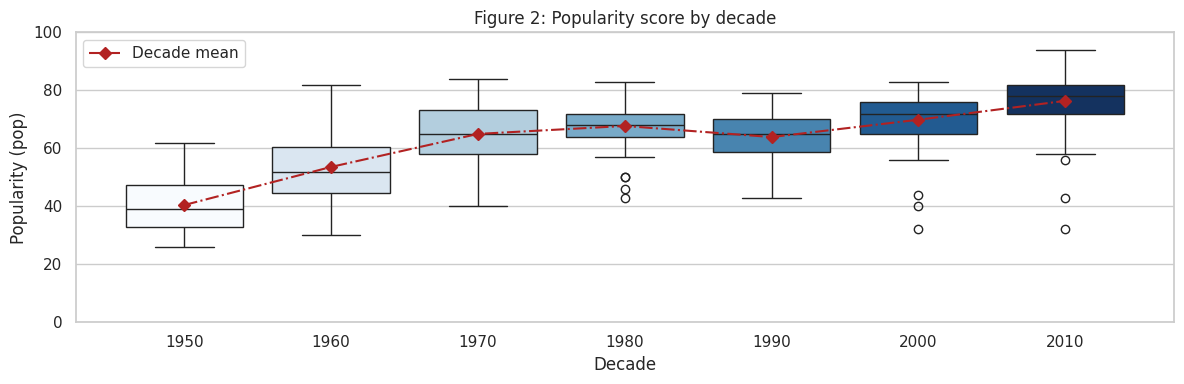

In [8]:
### Popularity by decade ###

# Single wide plot
fig, ax = plt.subplots(figsize=(12,4))

# Get ordered decades
decade_order = sorted(combined_df["decade"].unique())

# Boxplot of pop by decade ordered by decade
sns.boxplot(
    data=combined_df,
    x="decade", y="pop",
    order=decade_order,
    palette="Blues", hue="decade",
    legend=False, ax=ax
)

# Overlay the mean per decade for clarity
# Get decade means
decade_means = combined_df.groupby("decade")["pop"].mean()

# Plot the mean per decade ordered by decade
ax.plot(range(len(decade_order)), [decade_means[d] for d in decade_order],
        ls="dashdot", marker="D", color="firebrick", label="Decade mean", zorder=5)

ax.set_title("Figure 2: Popularity score by decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Popularity (pop)")
ax.set_ylim(0, 100.01)  # include 100% in y-axis range
ax.legend()
plt.tight_layout()
plt.show()

Popularity shows a clear upward trend across decades, consistent with Spotify's recency weighting. Songs from more recent decades accumulate streams more readily than older catalogue material. The 1990s shows a slight dip before rising again in the 2000s-2010s, likely reflecting the density of songs from that era diluting scores. This confirms `decade` as a meaningful feature while flagging a key limitation: the model may conflate "more recent" with "more popular" rather than capturing genuine timeless musical popularity.
### Feature Correlations

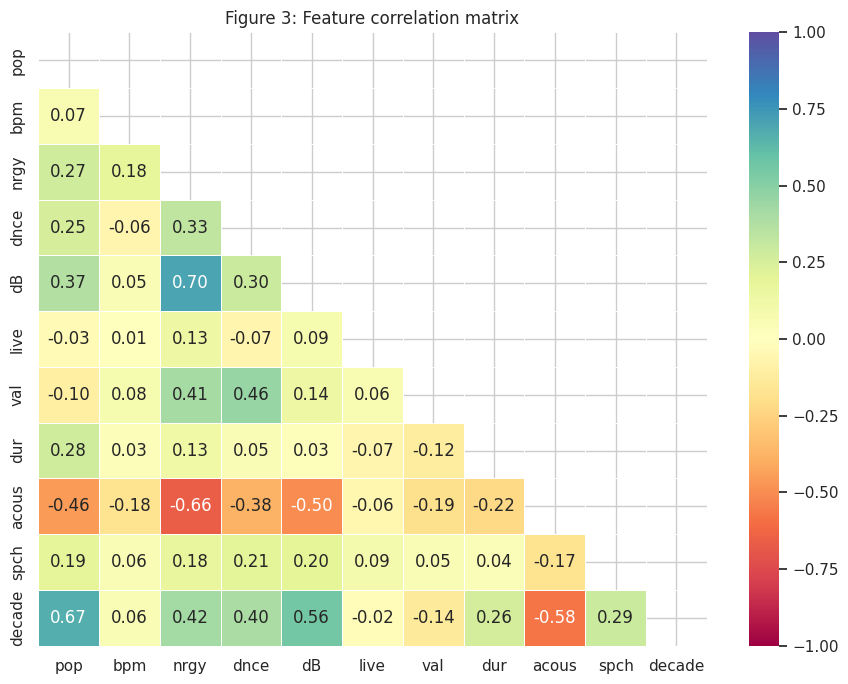

In [9]:
### Correlation heatmap ###

numeric_cols = ["pop", "bpm", "nrgy", "dnce", "dB", "live",
                "val", "dur", "acous", "spch", "decade"]

# Make correlation matrix
corr_matrix = combined_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

# Plot heatmap
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt=".2f",
    cmap="Spectral", center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title("Figure 3: Feature correlation matrix")
plt.tight_layout()
plt.show()

`decade` shows the strongest correlation with `pop` (r=0.67), followed by `acous` (r=-0.46). `bpm`, `live`, and `val` show negligible correlation (r<0.1) and are candidates for removal during feature selection. Notable correlation between `nrgy` and `dB` suggests potential multicollinearity which would interfer with a linear model.
### Genre Distribution

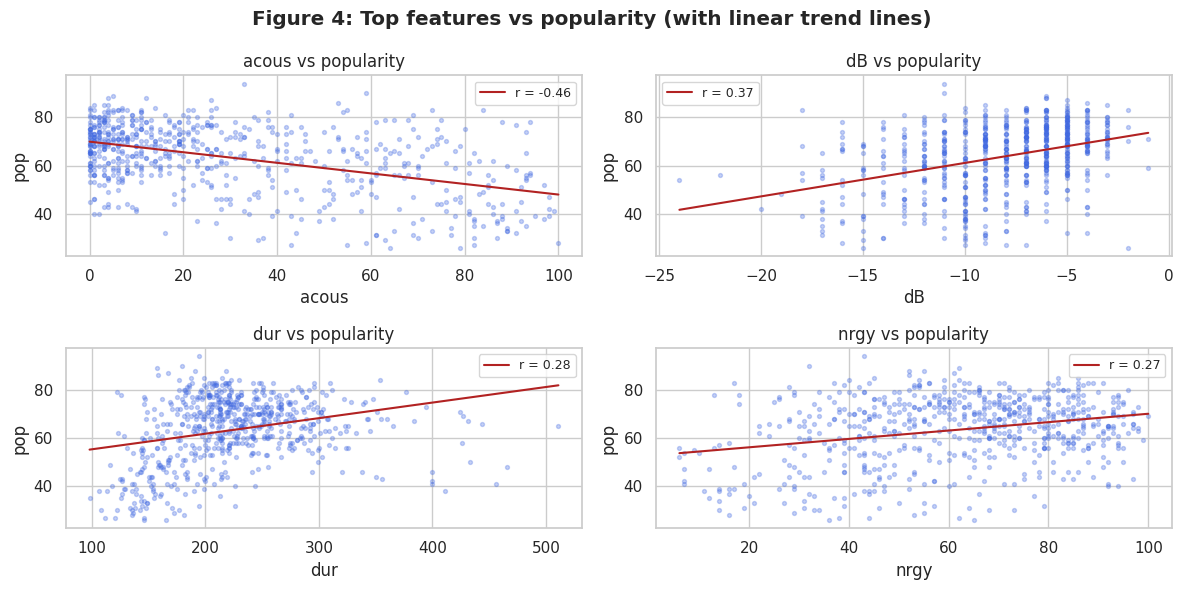

In [10]:
### Top feature scatter plots ###

# 2 x 2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12,6))
axes = axes.flatten()

# Pick the top 4 features by absolute correlation with pop, excluding decade
top_features = (
    corr_matrix["pop"]
    .drop(["pop", "decade"])
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

# For each top feature, plot a scatter plot of the feature vs popularity
for i, col in enumerate(top_features):
    axes[i].scatter(
        combined_df[col], combined_df["pop"],
        alpha=0.3, s=8, color="royalblue"
    )

    # Fit and overlay a trend line
    m, b = np.polyfit(combined_df[col], combined_df["pop"], 1)
    x_line = np.linspace(combined_df[col].min(), combined_df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="firebrick", linewidth=1.5,
                 label=f"r = {corr_matrix.loc[col,'pop']:.2f}")

    # Add labels and titles
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("pop")
    axes[i].set_title(f"{col} vs popularity")
    axes[i].legend(fontsize=9)

plt.suptitle("Figure 4: Top features vs popularity (with linear trend lines)",
             fontweight="bold")  # distinguise from subplots
plt.tight_layout()
plt.show()

Despite moderate correlation coefficients, scatter plots reveal no clean linear relationships between audio features and popularity.
- `acous` shows extreme clustering near zero.
- `dB` exhibits quantised banding.
- `dur`' has dense body of the data between 100-300 seconds shows no discernible trend with overall being driven by outliers.
- `nrgy` is widespread with a weak trend line.

This provides visual motivation for non-linear tree-based models over linear regression.
### Genre Distribution

Top 29 genres cover 80% of songs
Top 55 genres cover 90% of songs



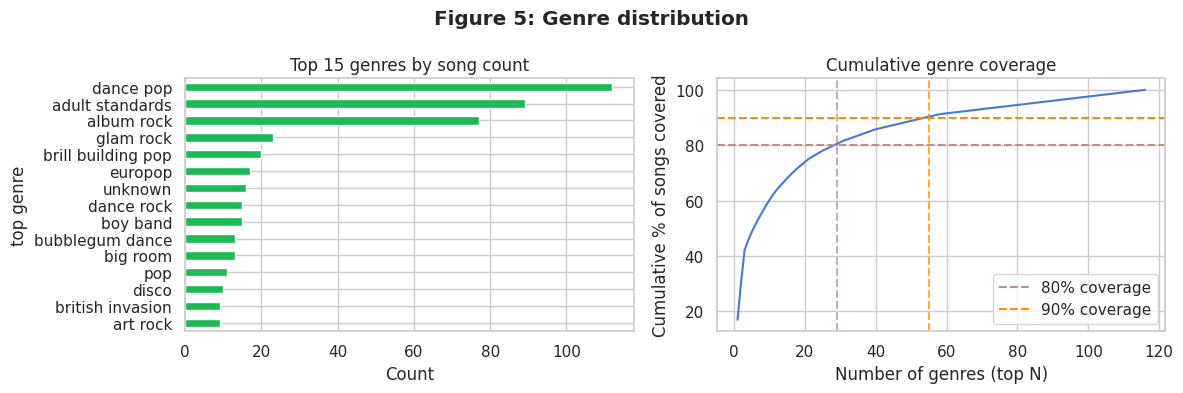

In [11]:
### Genre distribution ###

# Wide plot
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Get genre counts
genre_counts = combined_df["top genre"].value_counts()

# Top 15 genres by count
genre_counts.head(15).plot(
    kind="barh", ax=axes[0], color="#1DB954", edgecolor="white"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 genres by song count")
axes[0].set_xlabel("Count")

# Cumulative coverage — helps choose N
cumulative_pct = (genre_counts.cumsum() / genre_counts.sum() * 100)
axes[1].plot(range(1, len(cumulative_pct) + 1), cumulative_pct.values)
axes[1].axhline(80, color="rosybrown", ls="dashed", label="80% coverage")
axes[1].axhline(90, color="darkorange", ls="dashed", label="90% coverage")

# Thresholds for 80% and 90% coverage
n_80 = (cumulative_pct <= 80).sum() + 1
axes[1].axvline(n_80, color="rosybrown",  ls="dashed", alpha=0.75)
n_90 = (cumulative_pct <= 90).sum() + 1
axes[1].axvline(n_90, color="darkorange",  ls="dashed", alpha=0.75)

axes[1].set_xlabel("Number of genres (top N)")
axes[1].set_ylabel("Cumulative % of songs covered")
axes[1].set_title("Cumulative genre coverage")
axes[1].legend()

# Print top N values
print(f"Top {n_80} genres cover 80% of songs")
print(f"Top {n_90} genres cover 90% of songs\n")

plt.suptitle("Figure 5: Genre distribution", fontweight="bold")
plt.tight_layout()
plt.show()

The dataset contains over 100 unique genres with severe imbalance, with the top 3 genres accounting for approximately 50% of songs. The cumulative coverage plot shows no natural elbow, making a principled choice of N for top-N encoding for feature engineering difficult. This raises whether `genre` adds predictive value beyond `decade`, given their strong correlation (0.67).
### Genre Distribution Across Decades
To test whether genre and `decade` are correlated, which would make `genre` redundant as a feature, song counts were examined across both dimensions.

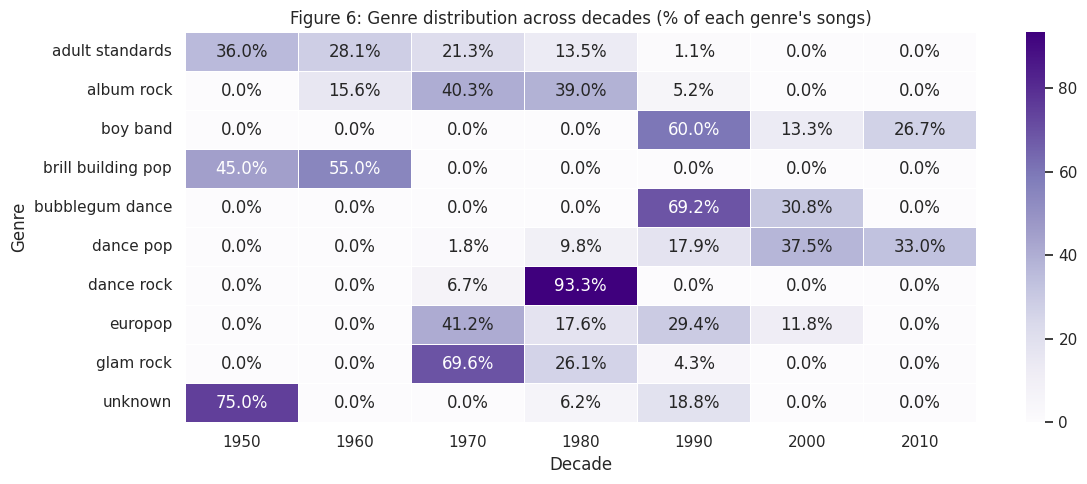

In [12]:
### Genre vs Decade heatmap ###

# Get top 10 genres by count
top_genres = combined_df["top genre"].value_counts().head(10).index

# Filter to only those genres
df_genre_decade = combined_df[combined_df["top genre"].isin(top_genres)]

# Create a crosstab of genre vs decade (normalised by genre row)
crosstab = pd.crosstab(
    df_genre_decade["top genre"],
    df_genre_decade["decade"],
    normalize="index"  # each row sums to 1 — shows distribution across decades
) * 100  # as percentages

# Format annotations with a % sign appended
annot = crosstab.round(1).astype(str) + "%"

fig, ax = plt.subplots(figsize=(12, 5))  # new fig size for better visibility
sns.heatmap(
    crosstab,
    annot=annot, fmt="",
    cmap="Purples",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Figure 6: Genre distribution across decades (% of each genre's songs)")
ax.set_xlabel("Decade")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()


Figure 6 confirms that genre is strongly concentrated within specific decades, for example 93% of dance rock songs originate from the 1980s and 70% of glam rock from the 1970s. `genre` and `decade` are therefore highly correlated, and including both would introduce redundancy without adding independent predictive signal. `genre` is excluded from the final modelling feature set.
## Feature Selection, Train/Test Split & Scaling
### Feature Selection
Based on EDA findings, the following features were exlcuded from modelling:
- `year` - incoherhant in 29.4% of rows. `decade` used instead.
- `top genre` - strongly correlated with `decade` (Figure 6), adds reduncancy
- `bpm`, `live`, `val` - near zero correlation with `pop` (Figure 3)
- `title`, `artist`, `incoherent_year` - indentifiers, no predictive value

The final feature set is: `decade`, `acous`, `dB`, `nrgy`, `dur`, `spch`

In [13]:
# Train test and cv config
RANDOM_STATE  = 13   # unlucky for some
TEST_SIZE = 0.2
CV_FOLDS = 5

# Set features and target
FEATURES = ["decade", "nrgy", "dnce", "dB", "dur", "acous", "spch"]
TARGET = "pop"

# Split data
X = combined_df[FEATURES]
y = combined_df[TARGET]

print("Features shape: ", X.shape)
print("Target shape : ", y.shape)

Features shape:  (660, 7)
Target shape :  (660,)


### Train/Test Split
Data was split 80/20 into training and test sets. `random_state = 13` is set throughout to ensure results are fully reproducible.

In [14]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split data using config params
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Training set: ", X_train.shape)
print("Test set: ", X_test.shape)

Training set:  (528, 7)
Test set:  (132, 7)


### Scaling
Features were scaled using `StandardScaler` for the linear regression model. The scaler was fitted on training data only. Applying it to the full dataset before splitting would allow test set information to influence the scaler, also known as data leakage. Tree-based models use the unscaled data directly as they are scale invariant.

In [15]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Instantiate scaler and fit on train data ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames to keep column names readable
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES, index=X_test.index)

# Check stats on scaled data - mean should be ~0 and std ~1 for all columns
print("Scaling applied. Verifying train set statistics:")
print(X_train_scaled.describe().round(2).head(3))

Scaling applied. Verifying train set statistics:
       decade   nrgy   dnce     dB    dur  acous   spch
count   528.0  528.0  528.0  528.0  528.0  528.0  528.0
mean     -0.0    0.0    0.0    0.0    0.0   -0.0    0.0
std       1.0    1.0    1.0    1.0    1.0    1.0    1.0


## Modelling
Three models were applied progressively, each motivated by the findings of the previous. A reusable `evaluate_model()` function reports RMSE, MAE, and R² on both training and test sets for consistent comparison. 5-fold cross-validation is applied to all models to provide a robust estimate of generalisation performance independent of the specific train/test split.

In [16]:
# Required imports for modelling
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

# Re-usable function for model performance metrics
def evaluate_model(name, y_train, y_pred_train, y_test, y_pred_test):
    metrics = {
        "Model": name,
        "Train RMSE": root_mean_squared_error(y_train, y_pred_train),
        "Test RMSE": root_mean_squared_error(y_test,  y_pred_test),
        "Train MAE": mean_absolute_error(y_train, y_pred_train),
        "Test MAE": mean_absolute_error(y_test,  y_pred_test),
        "Train R²": r2_score(y_train, y_pred_train),
        "Test R²": r2_score(y_test,  y_pred_test),
    }

    # Print the metrics in a nice table
    for k, v in metrics.items():
        print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}") # isinstance controls model name string
    return metrics

### Linear Regression (Baseline)
Linear regression assumes a linear relationship between features and the target. EDA scatter plots (Figure 4) suggested this assumption is unlikely to hold. The baseline is included to quantify this limitation and establish a performance floor for comparison of tree models.

In [17]:
# Fit a basic linear regression model, no hyperparameter tuning
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Store results of this and future models
results = []

# Evaluate the model on the training and test sets, store results in a list
results.append(evaluate_model(
    "Linear Regression",
    y_train, lr.predict(X_train_scaled),
    y_test, lr.predict(X_test_scaled)
))

Model: Linear Regression
Train RMSE: 10.188
Test RMSE: 9.325
Train MAE: 7.928
Test MAE: 7.230
Train R²: 0.473
Test R²: 0.443


In [18]:
# Cross-validate the model using 5-fold CV - loss function is negative RMSE
rmse_scores_lr = -cross_val_score(  # negate to get RMSE
    lr, X_train_scaled, y_train,
    cv=CV_FOLDS,
    scoring="neg_root_mean_squared_error"
)

print("Linear regression CV - Mean RMSE:", rmse_scores_lr.mean().round(3))
print("Linear regression CV - Std RMSE:", rmse_scores_lr.std().round(3))

Linear regression CV - Mean RMSE: 10.27
Linear regression CV - Std RMSE: 0.791


In [19]:
# Coefficients - decide later whether to include
coef_df = pd.DataFrame({
    "feature":     FEATURES,
    "coefficient": lr.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df.to_string(index=False))

feature  coefficient
 decade     7.530835
  acous    -2.405173
    dur     1.510228
   nrgy    -1.285282
     dB     0.767824
   spch     0.599671
   dnce    -0.053328


Linear regression achieved a test R² of 0.44, explaining less than half the variance in popularity. The near-zero coefficient for `dnce` (0.05) confirms it contributes negligible predictive power — it is removed from the feature set for subsequent models. The dominance of `decade` (coefficient 7.53) confirms EDA findings. CV RMSE of 10.27 (±0.79) is consistent with test RMSE
of 9.32, indicating a stable but underpowered model.

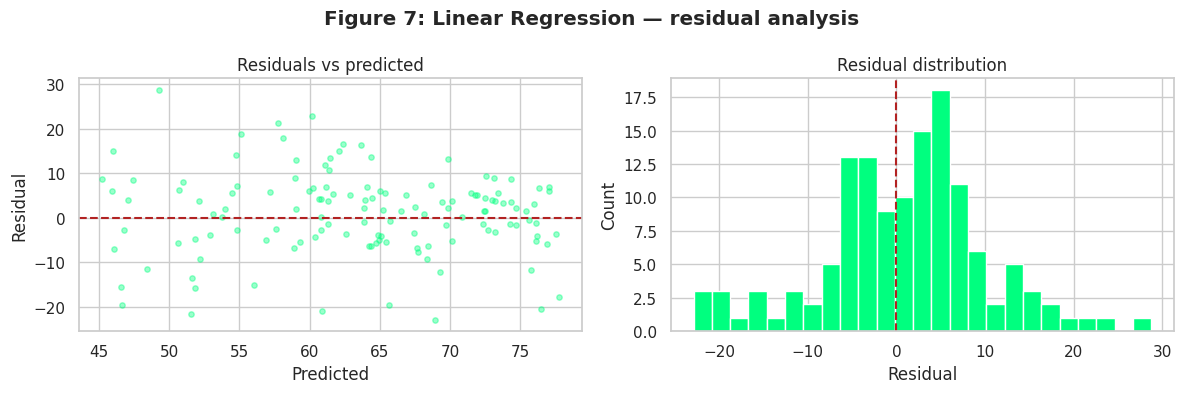

In [20]:
### Residuals plot of baseline model

# Calculate residuals
residuals_lr = y_test - lr.predict(X_test_scaled)

# 2 x 1 grid of plots
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Plot residuals vs predicted
axes[0].scatter(lr.predict(X_test_scaled), residuals_lr, alpha=0.4, s=15, color="springgreen")
axes[0].axhline(0, color="firebrick", linestyle="--")
axes[0].set(title="Residuals vs predicted", xlabel="Predicted", ylabel="Residual")

# Plot residual distribution
axes[1].hist(residuals_lr, bins=25, color="springgreen", edgecolor="white")
axes[1].axvline(0, color="firebrick", linestyle="--")
axes[1].set(title="Residual distribution", xlabel="Residual", ylabel="Count")

plt.suptitle("Figure 7: Linear Regression — residual analysis", fontweight="bold")
plt.tight_layout()
plt.show()

The residual diagnostics show no major violation of linearity assumptions, as residuals appear randomly dispersed around zero. Nevertheless, the large residual variance indicates significant unexplained variability, which implies that the model is limited rather than incorrectly applied

### Feature Refinement
The near-zero `dnce` coefficient identified above motivates its removal before proceeding. This is consistent with its low correlation in Figure 3.

In [21]:
# Update features set
FEATURES = ["decade", "nrgy", "dB", "dur", "acous", "spch"]

# Rebuild train/test sets with updated feature list
X_train, X_test = X_train[FEATURES], X_test[FEATURES]

# Scaled versions for any future linear models
X_train_scaled, X_test_scaled = X_train_scaled[FEATURES], X_test_scaled[FEATURES]

### Decision Tree
Decision trees partition the feature space into regions without assuming linearity, directly addressing the limitation identified in the baseline. An unpruned tree is deliberately used here to demonstrate overfitting, which motivates the ensemble approach that follows.

In [22]:
# Fit a decision tree model, no hyperparameter tuning
dt = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

# Evaluate the model on the training and test sets, store results in results
results.append(evaluate_model(
    "Decision Tree",
    y_train, dt.predict(X_train),
    y_test,  dt.predict(X_test)
))

Model: Decision Tree
Train RMSE: 0.000
Test RMSE: 11.516
Train MAE: 0.000
Test MAE: 9.098
Train R²: 1.000
Test R²: 0.151


In [23]:
# Cross-validate the model using 5-fold CV - loss function is negative RMSE
rmse_scores_dt = -cross_val_score(
    dt,
    X_train_scaled,
    y_train,
    cv=CV_FOLDS,
    scoring="neg_root_mean_squared_error"
)

print("Decision Tree CV - Mean RMSE:", rmse_scores_dt.mean().round(3))
print("Decision Tree CV - Std RMSE:", rmse_scores_dt.std().round(3))

Decision Tree CV - Mean RMSE: 12.91
Decision Tree CV - Std RMSE: 1.372


In [24]:
# Feature importance
importance_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.to_string(index=False))

feature  importance
 decade    0.569291
   nrgy    0.112333
  acous    0.110535
    dur    0.103430
   spch    0.060767
     dB    0.043644


In [25]:
# Tree depth and number of leaves
print(f"Tree depth: {dt.get_depth()}")
print(f"Number of leaves: {dt.get_n_leaves()}")

Tree depth: 20
Number of leaves: 482


The unpruned tree achieved perfect training performance (R²=1.00, RMSE=0.00) but collapsed to R²=0.15 on test data, worse than the linear baseline. With 482 leaves across 528 training samples the tree memorised individual songs rather than learning generalisable patterns. The tree depth of 20 on a dataset of this size is a clear indicator of overfitting. This directly motivates Random Forest, which addresses this issue by averaging across many trees utilising random subsets of features.
### Random Forest with Hyperparameter Tuning
Random Forest addresses the Decision Tree's overfitting by aggregating predictions across many decorrelated trees trained on bootstrap samples. GridSearchCV is used to identify optimal hyperparameters across 288 parameter combinations (1,440 total fits across 5 folds).

In [26]:
# import grid search cv
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = \
    {'n_estimators': [10, 50, 100, 200],
     'max_depth': [None, 10, 20, 30],
     'min_samples_split': [2, 5, 10],
     'min_samples_leaf': [1, 2, 4],
     'bootstrap': [True, False]}

# Instantiate the grid search model
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=CV_FOLDS,
    scoring="neg_mean_squared_error",
    n_jobs=-1,        # use all available cores
    verbose=1
)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding CV RMSE
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.3f}")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV RMSE: 9.360


GridSearch identified `max_depth=10`, `min_samples_leaf=4`, `min_samples_split=10`, and `n_estimators=200` as optimal parameters. The depth constraint in particular directly prevents the runaway tree growth seen in the Decision Tree algorithm.

In [27]:
# Take best model fit
rf = grid_search.best_estimator_

# Evaluate the model on the training and test sets, store results in results
results.append(evaluate_model(
    "Random Forest",
    y_train, rf.predict(X_train),
    y_test,  rf.predict(X_test)
))

Model: Random Forest
Train RMSE: 6.637
Test RMSE: 8.549
Train MAE: 5.022
Test MAE: 6.615
Train R²: 0.776
Test R²: 0.532


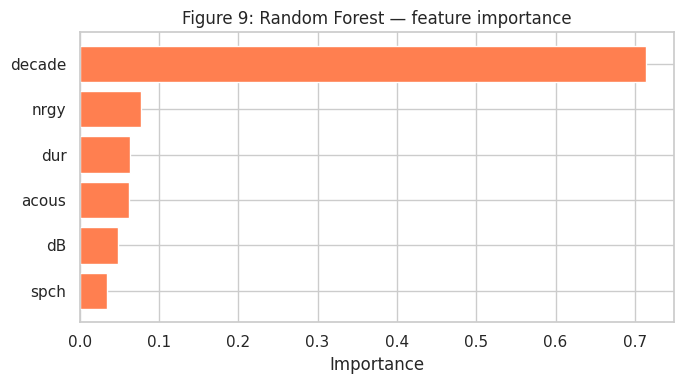

In [28]:
# Get feature importance in dataframe - sorted high to low
importance_df_rf = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

# Plot feature importance
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance_df_rf["feature"], importance_df_rf["importance"],
        color="coral", edgecolor="white")
ax.set_title("Figure 9: Random Forest — feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Random Forest achieved a test R² of 0.53, improving on both the linear baseline (0.44) and the Decision Tree (0.15). The train/test gap (0.78 vs 0.53) indicates residual overfitting despite regularisation through GridSearch. `decade` accounts for 72% of feature importance. The model is primarily learning when a song was released rather than what it sounds like, a limitation discussed in the conclusion.

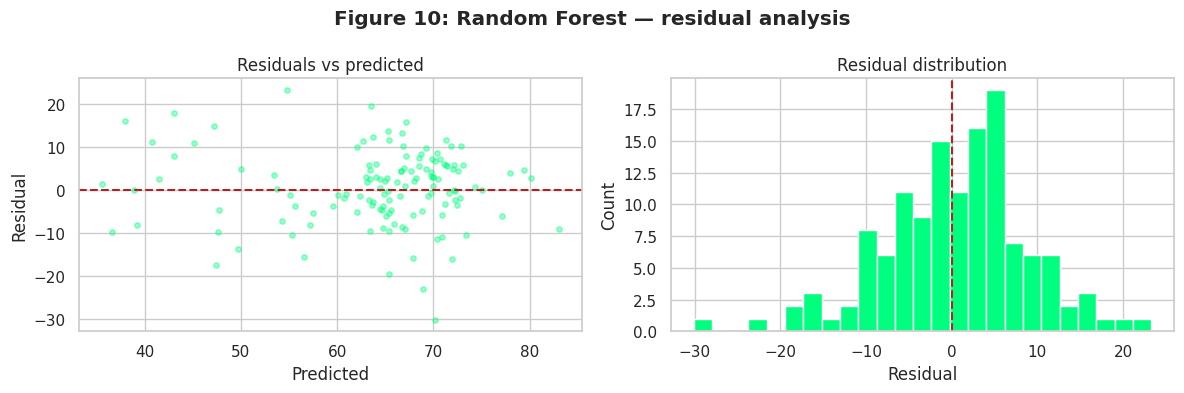

In [29]:
### Random Forest residuals

# Calculate residuals
residuals_rf = y_test - rf.predict(X_test)

# 2 x 1 grid of plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot residuals vs predicted
axes[0].scatter(rf.predict(X_test), residuals_rf, alpha=0.4, s=15, color="springgreen")
axes[0].axhline(0, color="firebrick", linestyle="--")
axes[0].set(title="Residuals vs predicted", xlabel="Predicted", ylabel="Residual")

# Plot residual distribution
axes[1].hist(residuals_rf, bins=25, color="springgreen", edgecolor="white")
axes[1].axvline(0, color="firebrick", linestyle="--")
axes[1].set(title="Residual distribution", xlabel="Residual", ylabel="Count")

plt.suptitle("Figure 10: Random Forest — residual analysis", fontweight="bold")
plt.tight_layout()
plt.show()

Compared to Figure 7, residuals are more tightly distributed and better centred on zero. The residuals vs predicted plot shows heteroscedasticity with variance larger at lower predicted values, where the model is less certain. This is consistent with the left-skewed target distribution (Figure 1) as fewer low-scoring songs in this curated dataset gives the model less to learn from at that end of the scale.
### Model Comparison


In [30]:
# Print results in a table
results_df = pd.DataFrame(results).set_index("Model")
print("=== MODEL COMPARISON TABLE ===\n")
print(results_df.round(3).to_string())

=== MODEL COMPARISON TABLE ===

                   Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Model                                                                           
Linear Regression      10.188      9.325      7.928     7.230     0.473    0.443
Decision Tree           0.000     11.516      0.000     9.098     1.000    0.151
Random Forest           6.637      8.549      5.022     6.615     0.776    0.532


The progression from Linear Regression to Random Forest shows a clear improvement in test performance. The Decision Tree demonstrates that increased model complexity without regularisation leads to worse generalisation than the simple baseline. Random Forest with tuning represents the best balance of train and test performance across all three models.
## Conclusion & Recommendation

Three models were applied to predict song popularity: Linear Regression as a baseline, Decision Tree to capture non-linear relationships, and Random Forest with GridSearch hyperparameter tuning as the final model.

| Model | Train R² | Test R² | Test RMSE |
|---|---|---|---|
| Linear Regression | 0.47 | 0.44 | 9.32 |
| Decision Tree | 1.00 | 0.15 | 11.52 |
| Random Forest | 0.78 | 0.53 | 8.55 |

**Random Forest is the recommended model**, achieving the best test performance (R²=0.53, RMSE=8.55) while maintaining a moderate train/test gap. GridSearch identified regularisation parameters (`max_depth=10`, `min_samples_leaf=4`) that controlled much of the overfitting exhibited by the unpruned Decision Tree.

Two limitations should be acknowledged. First, `decade` accounts for 72% of feature importance as the model is primarily learning when a song was released rather than what it sounds like. This limits its utility for predicting the popularity of future releases, where the recency advantage of a new release is unknown at the time of prediction. Second, a test R² of 0.53 means nearly half the variance in popularity remains unexplained, reflecting the inherently noisy nature of steaming music popularity.

Future work might explore models trained without `decade` to assess whether audio features alone carry sufficient predictive signal, accepting lower performance in exchange for a model whose predictions are grounded in musical attributes rather than when a song was released.